In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Perpustakaan

## Anggota

### Read csv

In [15]:
anggota = pd.read_csv("D:/KP_DIPUSIP/dataset/anggota.csv")
anggota.head()

,id_anggota,nama,jenis_kelamin,tanggal_lahir,nama_kabkotktp,nama_kecamatanktp,pekerjaan,tanggal_input
0,193578112.0,FEBY HIDAYAT,LAKI-LAKI,16/10/2000,KOTA SURABAYA,SUKO MANUNGGAL,MAHASISWA,11/04/2019
1,193578113.0,INDRAYANI KHOLIFAH,PEREMPUAN,25/03/2003,KOTA SURABAYA,GENTENG,PELAJAR,11/04/2019
2,19357818.0,KUMALA AYU SETYA DEWI,PEREMPUAN,31/05/1994,KOTA SURABAYA,RUNGKUT,PEG. SWASTA,11/04/2019
3,19357814.0,MITHA WEDDYANTI SAFITRI,PEREMPUAN,20/04/1997,KOTA SURABAYA,WIYUNG,PEG. SWASTA,11/04/2019
4,19357817.0,VERA ROSAYANI,PEREMPUAN,23/09/1985,KOTA SURABAYA,GUBENG,PEG. SWASTA,11/04/2019


In [16]:
anggota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51044 entries, 0 to 51043
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_anggota         51044 non-null  float64
 1   nama               51044 non-null  object 
 2   jenis_kelamin      51044 non-null  object 
 3   tanggal_lahir      51043 non-null  object 
 4   nama_kabkotktp     51044 non-null  object 
 5   nama_kecamatanktp  51044 non-null  object 
 6   pekerjaan          51044 non-null  object 
 7   tanggal_input      51044 non-null  object 
dtypes: float64(1), object(7)
memory usage: 3.1+ MB


In [17]:
anggota.isnull().sum()

id_anggota           0
nama                 0
jenis_kelamin        0
tanggal_lahir        1
nama_kabkotktp       0
nama_kecamatanktp    0
pekerjaan            0
tanggal_input        0
dtype: int64

In [18]:
anggota['tanggal_input'] = pd.to_datetime(
    anggota['tanggal_input'],
    dayfirst=True,
    errors='coerce'
)

In [19]:
# durasi anggota
anggota['tahun_daftar'] = anggota['tanggal_input'].dt.year
anggota['bulan_daftar'] = anggota['tanggal_input'].dt.to_period('M')

### EDA

In [20]:
anggota['tahun_daftar'].value_counts().sort_index()

tahun_daftar
2019     6221
2020     1579
2021     1630
2022     4999
2023     7334
2024    10781
2025    17211
2026     1289
Name: count, dtype: int64

In [21]:
anggota['jenis_kelamin'].value_counts(normalize=True)
print(f"LAKI-LAKI: {anggota['jenis_kelamin'].value_counts(normalize=True)['LAKI-LAKI']:.2%}")
print(f"PEREMPUAN: {anggota['jenis_kelamin'].value_counts(normalize=True)['PEREMPUAN']:.2%}")  


LAKI-LAKI: 37.31%
PEREMPUAN: 62.69%


<Axes: xlabel='bulan_daftar'>

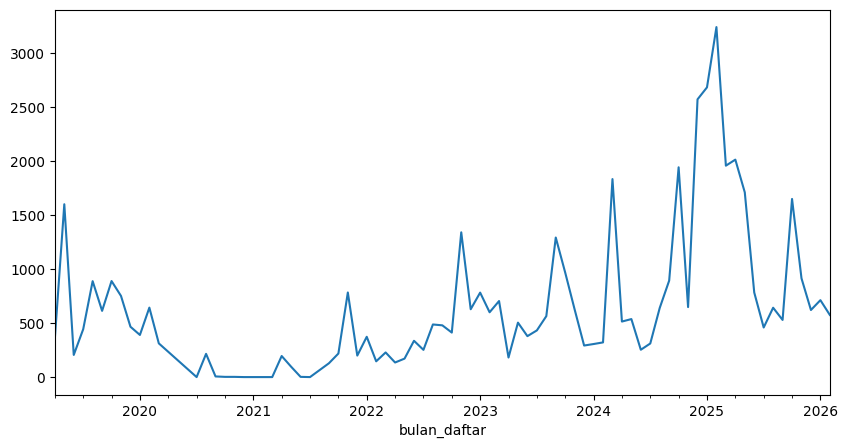

In [22]:
anggota.groupby('bulan_daftar').size().plot(figsize=(10,5))

<Axes: xlabel='pekerjaan'>

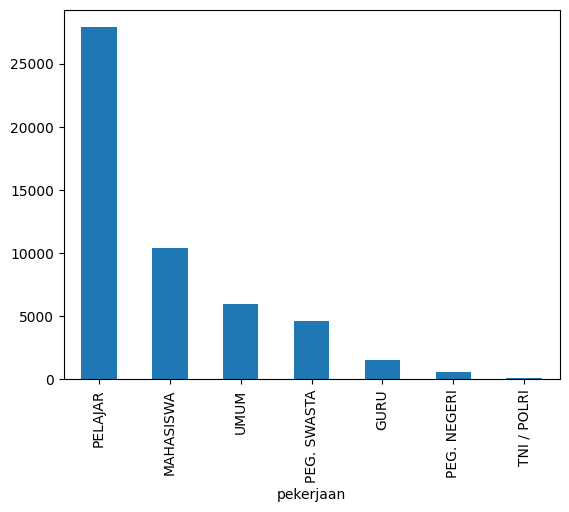

In [23]:
anggota['pekerjaan'].value_counts().head(10).plot(kind='bar')

## Pengunjung

### Merge dataset

In [24]:
files = ["D:/KP_DIPUSIP/dataset/pengunjung.csv", "D:/KP_DIPUSIP/dataset/pengunjung_2.csv"]

try:
    data = [pd.read_csv(f) for f in files]
    pengunjung = pd.concat(data, ignore_index=True)  # Gabung baris demi baris
except Exception as e:
    print(f"Terjadi error saat membaca/merge CSV: {e}")
    
pengunjung.head()

,id_anggota,nama,usia,pekerjaan,lokasi,tanggal_entri
0,1.935781e+10,YULIAR DECKY RAHMAWAN,44.0,PEGAWAI SWASTA,PERPUSTAKAAN BALAI PEMUDA,02/01/2022
1,1.935781e+10,RATIH FITRI PURNAMA,31.0,PEGAWAI SWASTA,PERPUSTAKAAN BALAI PEMUDA,02/01/2022
2,1.935781e+10,RAFI,13.0,PELAJAR,PERPUSTAKAAN BALAI PEMUDA,02/01/2022
3,1.935781e+10,KUPANG KRAJAN 1/73-B,5.0,PELAJAR,PERPUSTAKAAN BALAI PEMUDA,02/01/2022
4,1.935781e+09,MILANTA SUBENO,41.0,PEGAWAI SWASTA,PERPUSTAKAAN BALAI PEMUDA,02/01/2022


In [25]:
pengunjung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707401 entries, 0 to 1707400
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id_anggota     float64
 1   nama           object 
 2   usia           float64
 3   pekerjaan      object 
 4   lokasi         object 
 5   tanggal_entri  object 
dtypes: float64(2), object(4)
memory usage: 78.2+ MB


In [26]:
pengunjung.describe(include='all')

,id_anggota,nama,usia,pekerjaan,lokasi,tanggal_entri
count,8.906400e+04,1707400,1.048568e+06,1707401,1707401,1707401
unique,NaN,249791,NaN,8,549,1485
top,NaN,NABILA,NaN,PELAJAR,PERPUSTAKAAN BALAI PEMUDA,27/06/2023
freq,NaN,4254,NaN,1285901,337216,3586
mean,2.092699e+10,NaN,1.173029e+17,NaN,NaN,NaN
std,3.244790e+10,NaN,1.201176e+20,NaN,NaN,NaN
min,1.935151e+07,NaN,-3.000000e+01,NaN,NaN,NaN
25%,2.535781e+09,NaN,8.000000e+00,NaN,NaN,NaN
50%,2.235781e+10,NaN,1.000000e+01,NaN,NaN,NaN
75%,2.335781e+10,NaN,1.600000e+01,NaN,NaN,NaN


In [27]:
pengunjung.isnull().sum()

id_anggota       1618337
nama                   1
usia              658833
pekerjaan              0
lokasi                 0
tanggal_entri          0
dtype: int64

In [28]:
pengunjung.duplicated().sum()

68317

### Cleaning data

In [29]:
#buang nilai absurd pada usia
pengunjung['usia'] = pd.to_numeric(pengunjung['usia'], errors='coerce')
pengunjung.loc[(pengunjung['usia'] < 0) | (pengunjung['usia'] > 100), 'usia'] = None

In [30]:
pengunjung['kategori_usia'] = pd.cut(
    pengunjung['usia'], bins=[0, 12, 17, 25, 60, 100],
    labels=['Anak', 'Remaja', 'Pelajar', 'Dewasa', 'Lansia']
)

pengunjung['kategori_usia'] = pengunjung['kategori_usia'].cat.add_categories('Tidak Diketahui')
pengunjung['kategori_usia'] = pengunjung['kategori_usia'].fillna('Tidak Diketahui')

In [31]:
#status anggota untuk antisipasi null pada id_anggota
pengunjung['status_anggota'] = pengunjung['id_anggota'].notna().map({
    True: 'Anggota',
    False: 'Non-Anggota'
})

In [32]:
#format tanggal
pengunjung['tanggal_entri'] = pd.to_datetime(pengunjung['tanggal_entri'], dayfirst=True)
pengunjung['bulan'] = pengunjung['tanggal_entri'].dt.to_period('M')

In [33]:
pengunjung.isnull().sum()

id_anggota        1618337
nama                    1
usia               660070
pekerjaan               0
lokasi                  0
tanggal_entri           0
kategori_usia           0
status_anggota          0
bulan                   0
dtype: int64

In [34]:
pengunjung.head()

,id_anggota,nama,usia,pekerjaan,lokasi,tanggal_entri,kategori_usia,status_anggota,bulan
0,1.935781e+10,YULIAR DECKY RAHMAWAN,44.0,PEGAWAI SWASTA,PERPUSTAKAAN BALAI PEMUDA,2022-01-02,Dewasa,Anggota,2022-01
1,1.935781e+10,RATIH FITRI PURNAMA,31.0,PEGAWAI SWASTA,PERPUSTAKAAN BALAI PEMUDA,2022-01-02,Dewasa,Anggota,2022-01
2,1.935781e+10,RAFI,13.0,PELAJAR,PERPUSTAKAAN BALAI PEMUDA,2022-01-02,Remaja,Anggota,2022-01
3,1.935781e+10,KUPANG KRAJAN 1/73-B,5.0,PELAJAR,PERPUSTAKAAN BALAI PEMUDA,2022-01-02,Anak,Anggota,2022-01
4,1.935781e+09,MILANTA SUBENO,41.0,PEGAWAI SWASTA,PERPUSTAKAAN BALAI PEMUDA,2022-01-02,Dewasa,Anggota,2022-01


In [35]:
pengunjung.to_csv("pengunjung.csv", index=False)

### EDA

In [36]:
#komposisi pengunjung
pengunjung['status_anggota'].value_counts(normalize=True) * 100

status_anggota
Non-Anggota    94.783651
Anggota         5.216349
Name: proportion, dtype: float64

In [37]:
#distribusi usia
pengunjung['kategori_usia'].value_counts()

kategori_usia
Anak               693770
Tidak Diketahui    664847
Remaja             122611
Pelajar            120669
Dewasa             101080
Lansia               4424
Name: count, dtype: int64

In [38]:
#pekerjaan
pengunjung['pekerjaan'].value_counts().head(10)

pekerjaan
PELAJAR           1285901
UMUM               193780
MAHASISWA          146211
PEGAWAI SWASTA      28403
PEG. SWASTA         24112
GURU                19593
PEG. NEGERI          8191
TNI / POLRI          1210
Name: count, dtype: int64

In [39]:
#distribusi perpustakaan
pengunjung['lokasi'].value_counts().head(10)

lokasi
PERPUSTAKAAN BALAI PEMUDA    337216
PERPUSTAKAAN RUNGKUT          63752
TBM TAMAN FLORA                9775
TBM MUSEUM PENDIDIKAN          8768
TBM KELURAHAN PAGESANGAN       7745
TBM RW 5 KEMAYORAN             7301
TBM RW 1 GUNDIH                7265
TBM KELURAHAN JAMBANGAN        7112
TBM RW 4 KARAH                 6911
TBM RUSUN TANAH MERAH          6624
Name: count, dtype: int64

<Axes: xlabel='bulan'>

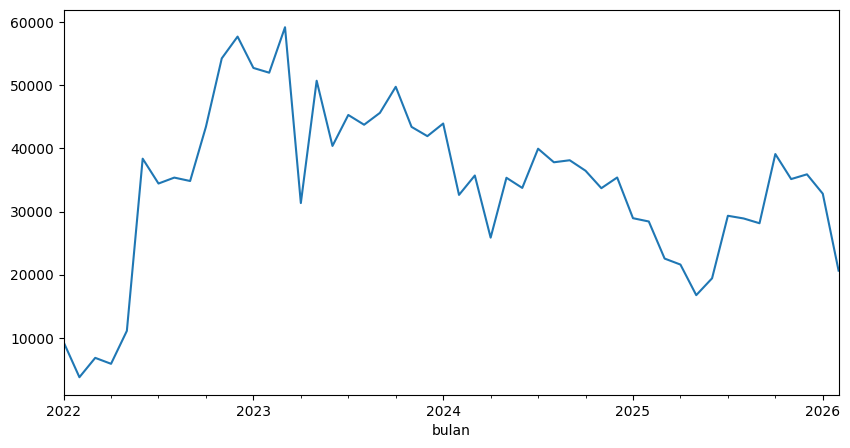

In [40]:
#tren pengunjung per bulan
pengunjung.groupby('bulan').size().plot(figsize=(10,5))

In [41]:
pd.crosstab(pengunjung['status_anggota'], pengunjung['pekerjaan'])

pekerjaan,GURU,MAHASISWA,PEG. NEGERI,PEG. SWASTA,PEGAWAI SWASTA,PELAJAR,TNI / POLRI,UMUM
status_anggota,,,,,,,,
Anggota,704,14128,376,0,2632,63509,84,7631
Non-Anggota,18889,132083,7815,24112,25771,1222392,1126,186149


## Koleksi Buku

In [42]:
buku = pd.read_csv('D:/KP_DIPUSIP/dataset/buku.csv')
buku.head()

,judul,nama_pengarang,nama_penerbit,tahun_terbit,jenis_buku,distribusi,lokasi
0,LUKA PEREMPUAN ASAP : AIR MATA DI ANTARA POHON...,NAFIAH AL MARAB,TINTA MEDINA,2017,BUKU DEWASA,2021-12-15,PERPUSTAKAAN RUNGKUT
1,PELAYANAN ANAK YANG HOLISTIK,TRI BUDIARDJO,ANDI OFFSET,2011,BUKU DEWASA,2021-12-16,PERPUSTAKAAN BALAI PEMUDA
2,FRANKFURT,NINNA ROSMINA,GRASINDO,2016,BUKU DEWASA,2021-12-17,PERPUSTAKAAN RUNGKUT
3,SAATNYA SIKAT GIGI! : YUK SEHAT BERSAMA GOYI D...,IRMALIA SUTANTO,POTATA PUBLISHING,2018,BUKU ANAK,2021-12-21,PERPUSTAKAAN RUNGKUT
4,GAGALNYA PERENCANAAN BISNIS,GUNAWAN ARDIYANTO,METAGRAF,2012,BUKU DEWASA,2021-12-21,TBM RW 5 NGINDEN JANGKUNGAN


In [43]:
buku.info()
buku.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569915 entries, 0 to 569914
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   judul           569915 non-null  object
 1   nama_pengarang  505312 non-null  object
 2   nama_penerbit   492009 non-null  object
 3   tahun_terbit    535346 non-null  object
 4   jenis_buku      569915 non-null  object
 5   distribusi      551820 non-null  object
 6   lokasi          569915 non-null  object
dtypes: object(7)
memory usage: 30.4+ MB


judul                 0
nama_pengarang    64603
nama_penerbit     77906
tahun_terbit      34569
jenis_buku            0
distribusi        18095
lokasi                0
dtype: int64

In [44]:
buku[buku.duplicated(subset=['judul'])]

,judul,nama_pengarang,nama_penerbit,tahun_terbit,jenis_buku,distribusi,lokasi
66,BUKU INTERAKTIF PAUD : ANAK HEWAN ( SINGA ) : ...,NaN,PT BHUANA ILMU POPULER,2017,BUKU ANAK,2022-12-18,PERPUSTAKAAN BALAI PEMUDA
90,BUKU PENGETAHUAN SERBA UNIK BERGAMBAR,KAK INTAN PUTRI,IDEA WORL KIDZ,2015,BUKU ANAK,2022-12-23,PERPUSTAKAAN RUNGKUT
110,FILSAFAT JAWA : MENGUAK FILOSOFI AJARAN DAN LA...,SRI WINTALA ACHMAD,ARASKA PUBLISHER,2017,BUKU DEWASA,2022-12-23,PERPUSTAKAAN RUNGKUT
114,KETERTINDASAN PEREMPUAN DALAM TRADISI KAWIN AN...,ROSRAMADHANA NASUTION,YAYASAN PUSTAKA OBOR INDONESIA,2016,BUKU DEWASA,2022-12-23,PERPUSTAKAAN BALAI PEMUDA
215,ENSIKLOPEDI POLITIK POPULER PEMBANGUNAN PANCAS...,NaN,NaN,NaN,BUKU DEWASA,2022-12-24,TBM RW 8 PAKIS
...,...,...,...,...,...,...,...
569910,STRATEGI MEMENANGKAN ISU DI SOCIAL MEDIA,JUBILEE ENTERPRISE,ELEX MEDIA KOMPUTINDO,2016,BUKU DEWASA,NaN,GUDANG KOLEKSI RUSAK
569911,NARUTO VOL. 41,KISHIMOTO MASASHI,PT. ELEX MEDIA KOMPUTINDO,2008,BUKU ANAK,NaN,GUDANG KOLEKSI RUSAK
569912,STORIES OF CANCERS SURVIVORS : KISAH PARA PASI...,"GOULD, ELIZABETH",IMANIA,2009,BUKU DEWASA,NaN,GUDANG KOLEKSI RUSAK
569913,MATA : SERI BIOLOGI ORGAN TUBUH MANUSIA,SISSY,ELEX MEDIA KOMPUTINDO,2011,BUKU ANAK,NaN,GUDANG KOLEKSI RUSAK


### Cleaning

In [45]:
buku['nama_pengarang'] = buku['nama_pengarang'].fillna('Tidak Diketahui')
buku['nama_penerbit'] = buku['nama_penerbit'].fillna('Tidak Diketahui')

In [46]:
buku['tahun_terbit'] = pd.to_numeric(buku['tahun_terbit'], errors='coerce')
buku.loc[
    (buku['tahun_terbit'] < 1900) | (buku['tahun_terbit'] > 2025),
    'tahun_terbit'
] = None

In [47]:
buku['distribusi'] = pd.to_datetime(buku['distribusi'], errors='coerce')
buku['tahun_distribusi'] = buku['distribusi'].dt.year
buku['bulan_distribusi'] = buku['distribusi'].dt.to_period('M')

In [48]:
tahun_sekarang = pd.Timestamp('today').year
buku['umur_buku'] = tahun_sekarang - buku['tahun_terbit']

In [49]:
buku['umur_buku'] = pd.cut(
    buku['umur_buku'],
    bins=[0, 5, 10, 20, 100],
    labels=['Sangat Baru', 'Baru', 'Sedang', 'Lama']
)

buku['umur_buku'] = buku['umur_buku'].cat.add_categories('Tidak Diketahui')
buku['umur_buku'] = buku['umur_buku'].fillna('Tidak Diketahui')

In [50]:
buku.isnull().sum() 
buku.head()

,judul,nama_pengarang,nama_penerbit,tahun_terbit,jenis_buku,distribusi,lokasi,tahun_distribusi,bulan_distribusi,umur_buku
0,LUKA PEREMPUAN ASAP : AIR MATA DI ANTARA POHON...,NAFIAH AL MARAB,TINTA MEDINA,2017.0,BUKU DEWASA,2021-12-15,PERPUSTAKAAN RUNGKUT,2021.0,2021-12,Baru
1,PELAYANAN ANAK YANG HOLISTIK,TRI BUDIARDJO,ANDI OFFSET,2011.0,BUKU DEWASA,2021-12-16,PERPUSTAKAAN BALAI PEMUDA,2021.0,2021-12,Sedang
2,FRANKFURT,NINNA ROSMINA,GRASINDO,2016.0,BUKU DEWASA,2021-12-17,PERPUSTAKAAN RUNGKUT,2021.0,2021-12,Baru
3,SAATNYA SIKAT GIGI! : YUK SEHAT BERSAMA GOYI D...,IRMALIA SUTANTO,POTATA PUBLISHING,2018.0,BUKU ANAK,2021-12-21,PERPUSTAKAAN RUNGKUT,2021.0,2021-12,Baru
4,GAGALNYA PERENCANAAN BISNIS,GUNAWAN ARDIYANTO,METAGRAF,2012.0,BUKU DEWASA,2021-12-21,TBM RW 5 NGINDEN JANGKUNGAN,2021.0,2021-12,Sedang


In [51]:
buku.to_csv("koleksi buku.csv", index=False)

### EDA

In [52]:
buku['jenis_buku'].value_counts(normalize=True) * 100

jenis_buku
BUKU DEWASA       55.505470
BUKU ANAK         41.179299
BUKU REFERENSI     3.315231
Name: proportion, dtype: float64

In [53]:
buku['lokasi'].value_counts().head(10)

lokasi
PERPUSTAKAAN RUNGKUT         43500
PERPUSTAKAAN BALAI PEMUDA    21684
GUDANG KOLEKSI RUSAK         10851
GUDANG KOLEKSI BAGUS          7245
TBM KELURAHAN NGAGELREJO      4502
TBM KELURAHAN PAGESANGAN      3638
TBM KELURAHAN SEMOLOWARU      3205
TBM RUSUN INDRAPURA           3081
TBM TAMAN FLORA               2911
TBM RUSUN TANAH MERAH         2847
Name: count, dtype: int64

<Axes: xlabel='bulan_distribusi'>

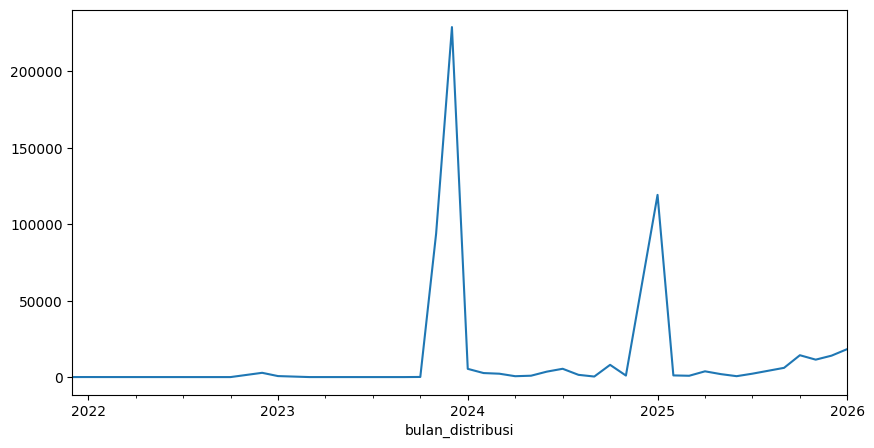

In [54]:
buku.groupby('bulan_distribusi').size().plot(figsize=(10,5))

In [55]:
buku['nama_penerbit'].value_counts().head(10)

nama_penerbit
Tidak Diketahui                                                                77906
KEMENTERIAN PENDIDIKAN, KEBUDAYAAN, RISET, DAN TEKNOLOGI REPUBLIK INDONESIA    57019
ELEX MEDIA KOMPUTINDO                                                          21143
TIGA ANANDA                                                                    20544
ERLANGGA FOR KIDS                                                              14377
GRAMEDIA PUSTAKA UTAMA                                                         11708
ANDI                                                                           11703
DIVA PRESS                                                                      9682
THE ASIA FOUNDATION                                                             8680
KANISIUS                                                                        7924
Name: count, dtype: int64

In [56]:
buku['umur_buku'].value_counts(normalize=True) * 100

umur_buku
Sedang             56.850408
Baru               16.310327
Sangat Baru        12.856830
Lama                7.030698
Tidak Diketahui     6.951738
Name: proportion, dtype: float64

# Peminjaman

## Read dataset

In [57]:
pinjam = pd.read_csv("D:/KP_DIPUSIP/dataset/peminjaman.csv")
pinjam.head()

,id_anggota,nama,usia,lokasi,judul_buku,pengarang_buku,penerbit_buku,tanggal_pinjam
0,1.935781e+10,TRIUNI KRISMAYANTI,48,PERPUSTAKAAN RUNGKUT,"BISMILLAH, CINTA",MERRY MAETA SARI,GRAMEDIA PUSTAKA UTAMA,06/08/2019
1,1.935781e+10,RAUL RAKA LITMANEN,23,PERPUSTAKAAN BALAI PEMUDA,MENGAIS JEJAK PERADAPAN BUMI KAHURIPAN,AGUS SUBANDRIYO,BERANDA,06/08/2019
2,1.935781e+10,CITRA WULANDARI,24,PERPUSTAKAAN BALAI PEMUDA,ANYELIR UNTUK ALYSSA,NABILLA ANASTY FAHARIA,PASTEL BOOKS,06/08/2019
3,1.935781e+10,MUHAMMAD RAFI PRADIPA PUTRA KOTO,22,PERPUSTAKAAN BALAI PEMUDA,MISTERI BENANG MERAH KEJAHATAN DAN MISTERI EMP...,"DOYLE, SIR ARTHUR SONAN",NaN,06/08/2019
4,1.935781e+10,ELZA MARETA VINDIATAMA S.,25,PERPUSTAKAAN BALAI PEMUDA,IT HURTS KETIKA MENCINTAIMU ADALAH SAKIT UNTUKKU,GOGOR SUBYAKTO,SHEILA,06/08/2019


In [58]:
pinjaman.info() 
pinjaman.isnull().sum() 

NameError: name 'pinjaman' is not defined

In [ ]:
pinjam['tanggal_pinjam'] = pd.to_datetime(
    pinjam['tanggal_pinjam'],
    dayfirst=True,
    errors='coerce'
)

pinjam['bulan_pinjam'] = pinjam['tanggal_pinjam'].dt.to_period('M')
pinjam['tahun_pinjam'] = pinjam['tanggal_pinjam'].dt.year

In [ ]:
pinjam['kategori_usia'] = pd.cut(
    pinjam['usia'],
    bins=[0, 12, 17, 25, 60, 100],
    labels=['Anak', 'Remaja', 'Pelajar', 'Dewasa', 'Lansia']
)

In [ ]:
#missing value pada pengarang dan penerbit
pinjam['pengarang_buku'] = pinjam['pengarang_buku'].fillna('Tidak Diketahui')
pinjam['penerbit_buku'] = pinjam['penerbit_buku'].fillna('Tidak Diketahui')

### EDA

In [ ]:
len(pinjam)

89071

In [ ]:
pinjam['kategori_usia'].value_counts()

kategori_usia
Dewasa     36330
Pelajar    27722
Anak       12188
Remaja     10435
Lansia      2088
Name: count, dtype: int64

In [ ]:
pinjam['lokasi'].value_counts().head(10)

lokasi
PERPUSTAKAAN BALAI PEMUDA    52121
PERPUSTAKAAN RUNGKUT         36950
Name: count, dtype: int64

In [ ]:
pinjam['judul_buku'].value_counts().head(10)

judul_buku
BULAN.                                           202
KOMET MINOR                                      172
KOMET                                            162
CEROS DAN BATOZAR                                137
TENTANG KAMU                                     117
SELAMAT DATANG DI EQUESTRIA : MY LITTLE PONY     107
KISAH TANAH JAWA INVESTIGASI MITOS DAN MISTIS     98
WHY ? SOFTWARE DAN CODING =                       98
KEAJAIBAN TOKO KELONTONG NAMIYA :                 93
MATAHARI                                          91
Name: count, dtype: int64

<Axes: xlabel='bulan_pinjam'>

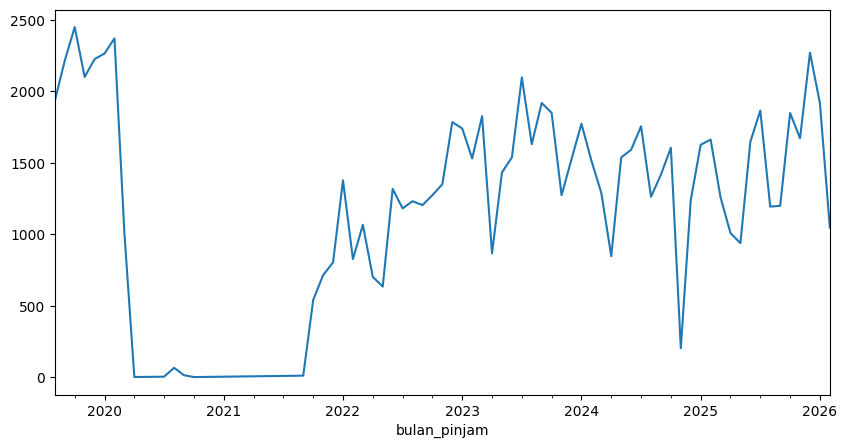

In [ ]:
pinjam.groupby('bulan_pinjam').size().plot(figsize=(10,5))

<Axes: ylabel='judul_buku'>

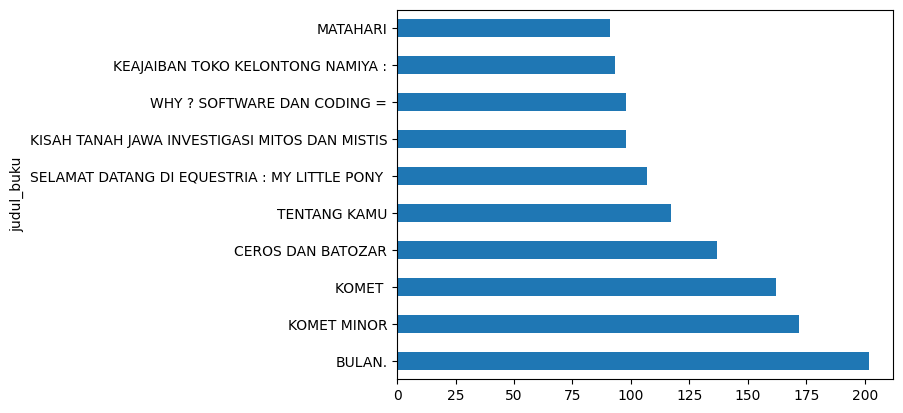

In [ ]:
pinjam['judul_buku'].value_counts().head(10).plot(kind='barh')

# KEARSIPAN

## Jenis Arsip

In [ ]:
arsip = pd.read_csv("D:/KP_DIPUSIP/dataset/jenis_arsip.csv")
arsip.head()

,kode_provinsi,nama_provinsi,kode_kota,nama_kota,jenis,jumlah,satuan,bulan,tahun
0,35,JAWA TIMUR,3578,KOTA SURABAYA,Tekstual Statis,13390,Item,juli,2022
1,35,JAWA TIMUR,3578,KOTA SURABAYA,Tekstual Inaktif,50657,Item,juli,2022
2,35,JAWA TIMUR,3578,KOTA SURABAYA,Peta,2594,Item,juli,2022
3,35,JAWA TIMUR,3578,KOTA SURABAYA,Foto,2755,Item,juli,2022
4,35,JAWA TIMUR,3578,KOTA SURABAYA,Video,91,CD,juli,2022


In [ ]:
arsip.info()
arsip.isnull().sum()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   kode_provinsi  210 non-null    int64 
 1   nama_provinsi  210 non-null    object
 2   kode_kota      210 non-null    int64 
 3   nama_kota      210 non-null    object
 4   jenis          210 non-null    object
 5   jumlah         210 non-null    int64 
 6   satuan         210 non-null    object
 7   bulan          210 non-null    object
 8   tahun          210 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 14.9+ KB


kode_provinsi    0
nama_provinsi    0
kode_kota        0
nama_kota        0
jenis            0
jumlah           0
satuan           0
bulan            0
tahun            0
dtype: int64

In [ ]:
bulan_order = [
    'januari','februari','maret','april','mei','juni',
    'juli','agustus','september','oktober','november','desember'
]

arsip['bulan'] = pd.Categorical(arsip['bulan'], categories=bulan_order, ordered=True)

In [ ]:
arsip['jumlah'].sum()

9965378

In [ ]:
arsip.groupby('jenis')['jumlah'].sum().sort_values(ascending=False)

jenis
Tekstual Inaktif    9042184
Tekstual Statis      644453
Peta                 163572
Foto                 111347
Video                  3822
Name: jumlah, dtype: int64

In [ ]:
arsip['satuan'].value_counts()

satuan
Item    168
CD       42
Name: count, dtype: int64

C:\Users\Aulia anantiyo\AppData\Local\Temp\ipykernel_9708\2246204476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arsip.groupby('bulan')['jumlah'].sum().plot(kind='barh')


<Axes: ylabel='bulan'>

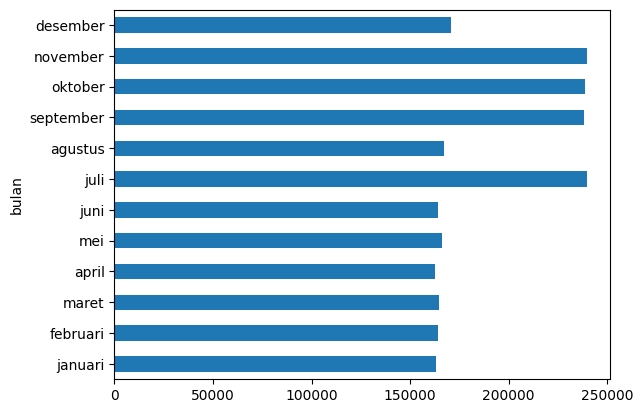

In [ ]:
arsip.groupby('bulan')['jumlah'].sum().plot(kind='barh')

In [ ]:
arsip.groupby('tahun')['jumlah'].sum()

tahun
2022     347435
2023     772882
2024    1158279
2025    6575445
2026    1111337
Name: jumlah, dtype: int64

<Axes: ylabel='jenis'>

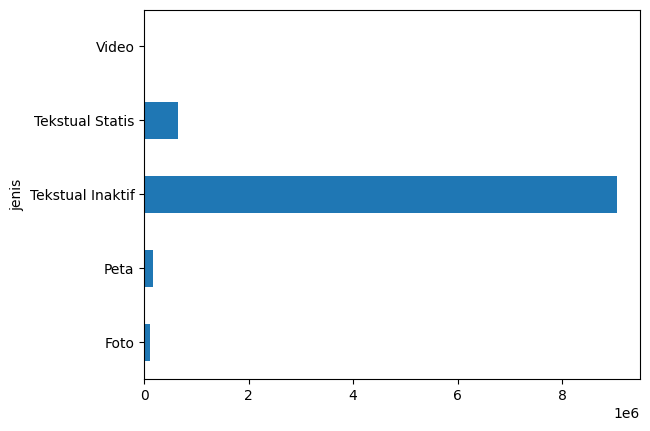

In [ ]:
arsip.groupby('jenis')['jumlah'].sum().plot(kind='barh')

In [ ]:
pd.pivot_table(
    arsip,
    values='jumlah',
    index='bulan',
    columns='jenis',
    aggfunc='sum'
)

jenis,Foto,Peta,Tekstual Inaktif,Tekstual Statis,Video
bulan,,,,,
januari,6165,7282,121948,27614,182
februari,6165,7282,122698,27644,182
maret,6165,7282,123448,27674,182
april,3096,7282,124198,27699,182
mei,6165,7282,124948,27724,182
juni,3096,7282,125698,27749,182
juli,8920,9876,177105,43373,273
agustus,3096,7282,126448,29988,182
september,5851,9876,178605,43433,273


In [ ]:
pd.pivot_table(
    arsip,
    values='jumlah',
    index='tahun',
    columns='jenis',
    aggfunc='sum'
)

jenis,Foto,Peta,Tekstual Inaktif,Tekstual Statis,Video
tahun,,,,,
2022,13775,12970,253285,66950,455
2023,30305,28534,565477,147565,1001
2024,19437,56256,895992,185502,1092
2025,40920,56256,6268330,208847,1092
2026,6910,9556,1059100,35589,182


C:\Users\Aulia anantiyo\AppData\Local\Temp\ipykernel_9708\2053681900.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arsip.groupby('bulan')['jumlah'].sum().plot()


<Axes: xlabel='bulan'>

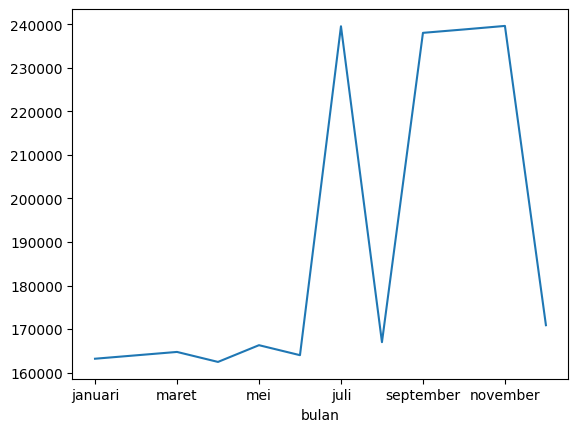

In [ ]:
arsip.groupby('bulan')['jumlah'].sum().plot()

In [ ]:
arsip['kategori_arsip'] = arsip['jenis'].replace({
    'Tekstual Statis': 'Dokumen',
    'Tekstual Inaktif': 'Dokumen',
    'Foto': 'Visual',
    'Video': 'Visual',
    'Peta': 'Geospasial'
})

In [ ]:
arsip.groupby('kategori_arsip')['jumlah'].sum()

kategori_arsip
Dokumen       9686637
Geospasial     163572
Visual         115169
Name: jumlah, dtype: int64